In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# from kret_studies import *
# from kret_studies.notebook import *
# from kret_studies.complex import *

# logger = get_notebook_logger()

In [3]:
from waymo_agent.notebook_imports import *

In [4]:
from functools import cache

In [5]:
from waymo_agent import *
from waymo_agent.osmnx import *
from waymo_agent.data_classes import *
from waymo_agent.action_heuristic import *
from waymo_agent.graph_env import *
from waymo_agent.simulation import *
from waymo_agent.action_heuristic.heuristic_simple import PricingAgent, DispatchAgent, RepositionAgent
from waymo_agent.models.ppo_model import RideShareActorCritic
from waymo_agent.graph_env.ENV import RideShareEnv
from waymo_agent.models.ppo_model import *

In [60]:
from waymo_agent.models.ppo_model import *
from waymo_agent.models.evaluate import *
from waymo_agent.models.train_utils import *

In [6]:
from kret_sandbox.VIS import dtt
from kret_sandbox.exp_decay import exp_decay_half_life, get_gamma_from_half_life

In [7]:
def get_obs_tuple(env: RideShareEnv):
    veh = env.observation_curr["vehicles"]
    req = env.observation_curr["pending_requests"]
    rides = env.observation_curr["active_rides"]
    return veh, req, rides


def get_obs_tuple_from_obs(obs: ObservationDict):
    veh = obs["vehicles"]
    req = obs["pending_requests"]
    rides = obs["active_rides"]
    return veh, req, rides

# Run Sim

In [82]:
env_cfg = EnvConfig(max_episode_steps=60 * 1)
plt_cfg = PlotConfig()
env_model = RideShareEnv(env_cfg, plt_cfg)

Assigned lambda values to nodes. Total lambda: 2.3460 (target: 2.3460)


In [83]:
GAMMA = get_gamma_from_half_life(env_cfg.max_episode_steps // 2)
round(GAMMA, 5)

0.97716

In [84]:
def discounted_rewards(rewards: np.ndarray, gamma: float = 0.997) -> np.ndarray:
    """
    Discount rewards using discount factor gamma.
    """
    disc_schedule = exp_decay_half_life(len(rewards), gamma=gamma)
    return rewards * disc_schedule


def get_act_dict(agents: tuple[PricingAgent, DispatchAgent, RepositionAgent], obs: ObservationDict) -> ActionDict:
    price_agent, dispatch_agent, reposition_agent = agents
    prices = price_agent.price(obs)
    dispatch_actions = dispatch_agent.dispatch(obs)
    reposition_actions = reposition_agent.reposition(obs)

    action_agent: ActionDict = {
        "prices": prices,
        "dispatch": dispatch_actions,
        "reposition": reposition_actions,
    }
    return action_agent

In [85]:
@torch.no_grad()
def run_model_simulation(
    env_curr: RideShareEnv,
    model: RideShareActorCritic,
    num_iter: int = 1,
    gamma: float = GAMMA,
    deterministic: bool = False,
):
    """
    Returns:
      REWARDS: list[episode][t] discounted reward_t
      OBS:     list[episode][t] obs dict (numpy)
      ACT:     list[episode][t] action dict (numpy)
    """
    model.eval()

    REWARDS: list[np.ndarray] = []
    OBS: list[list[dict[str, np.ndarray]]] = []
    ACT: list[list[dict[str, np.ndarray]]] = []
    TERMINATED: list[bool] = []
    TRUNCATED: list[bool] = []

    for i in tqdm(range(num_iter), desc="model rollout"):
        # tqdm.write(f"Starting episode {i+1}/{num_iter}...")
        obs_np, _info = env_curr.reset()
        terminated = False
        truncated = False
        done = False

        rews_raw: list[float] = []
        obs_list: list[dict[str, np.ndarray]] = []
        act_list: list[dict[str, np.ndarray]] = []

        while not done:
            # tqdm.write(f"Step {env_curr.current_step}/{env_curr.config.max_episode_steps}")
            obs_list.append(obs_np)

            obs_t = obs_pd_to_torch(obs_np)

            act_t = model.act(obs_t, deterministic=deterministic)
            act_np = action_torch_to_numpy(act_t)
            env_curr._validate_action(act_np)
            act_list.append(act_np)

            obs_np, reward, terminated, truncated, _info = env_curr.step(act_np)  # type: ignore[arg-type]
            # print(f"Reward: {reward}")
            rews_raw.append(float(reward))
            done = bool(terminated) or bool(truncated)

        rews = discounted_rewards(np.array(rews_raw, dtype=np.float32), gamma=gamma)
        REWARDS.append(rews)
        OBS.append(obs_list)
        ACT.append(act_list)
        TERMINATED.append(terminated)
        TRUNCATED.append(truncated)

    return REWARDS, OBS, ACT, TERMINATED, TRUNCATED

In [86]:
model = RideShareActorCritic(env_model)
cfg_ppo = PPOTrainConfig(total_steps=800, gamma=GAMMA, log_every_updates=1)

In [87]:
REWARDS, OBS, ACT, TERMINATED, TRUNCATED = run_model_simulation(env_model, model, num_iter=1)

model rollout:   0%|          | 0/1 [00:00<?, ?it/s]

In [88]:
TERMINATED, TRUNCATED

([False], [True])

In [89]:
env_model._rewards

{'penalty_multiple_dispatch_assignment': 0.0,
 'penalty_assign_to_unavailable_vehicle': 0.4,
 'distance_penalty_xy_normed': 0.0,
 'penalty_rejected': np.float64(-0.0),
 'penalty_expire': np.float64(-0.0),
 'ride_reward_total': np.float64(-3.192963141031612)}

In [90]:
# import importlib
# import waymo_agent.data_classes.enriched_df_base

# _ = importlib.reload(waymo_agent.data_classes.enriched_df_base)

## NN Actor-Critic

In [91]:
pprint(cfg_ppo)

PPOTrainConfig(total_steps=800,
               gamma=0.9771599684342459,
               gae_lambda=0.95,
               lr=0.0003,
               clip_eps=0.2,
               vf_coef=0.5,
               ent_coef=0.01,
               max_grad_norm=0.5,
               update_epochs=4,
               minibatch_size=256,
               deterministic_eval=True,
               log_every_updates=1,
               eval_episodes=2,
               eval_every_updates=5,
               patience=20,
               min_delta=0.001,
               save_best=True)


In [92]:
pprint(env_cfg)

EnvConfig(map_name='manhattan-sparse-782-nodes-enriched.graphml',
          map_dir=PosixPath('/Users/Akseldkw/coding/Columbia/RL-Project/maps'),
          vehicle_per_node=0.03,
          max_vehicles=50,
          time_step_delta=datetime.timedelta(seconds=60),
          max_episode_steps=60,
          day_per_week=7,
          hours_per_day=24,
          lambda_per_node=0.003,
          lambda_variation_coef=2.0,
          max_new_requests_per_step=None,
          max_pending_requests=50,
          max_wait_time_minutes=15,
          max_price=inf,
          invalid_id=-1,
          acceptance_margin_weight=-2.0,
          acceptance_supply_demand_weight=3.0,
          battery_consumption_per_km=0.01,
          charge_rate_per_minute=0.12,
          min_battery_for_assignment=0.2,
          chargable_node_ratio=0.01,
          max_chargers_per_node=1,
          penalty_rejected=-1.0,
          penalty_expire=-2.0,
          penalty_overflow=-1.5,
          reward_frac_ride_completio

In [93]:
_ = env_model.reset()

In [94]:
model, logs = ppo_model.train_ppo(
    env_model, model, train_cfg=cfg_ppo, save_path=MODEL_WEIGHT_DIR / "ppo_model_final.pt"
)

PPO steps:   0%|          | 0/800 [00:00<?, ?step/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

...

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

PPO update epochs:   0%|          | 0/4 [00:00<?, ?it/s]

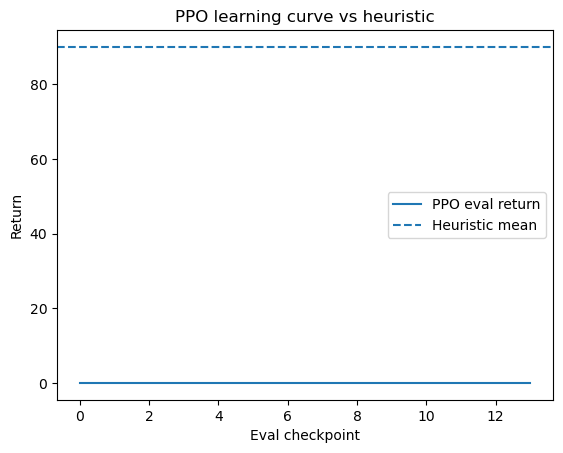

In [95]:
plot_learning_curve_vs_baseline(logs, heur_mean=env_cfg.max_episode_steps * 1.5)

In [96]:
# save_weights(model, MODEL_WEIGHT_DIR / "ppo_model_final.pt")